# Рубежный контроль №1 - Отчёт

**Имя** -Фон Маунг Хтве  
**Группа** - ИУ5И-23М  
**Номер в списке** - 2  
**Номер варианта** - 17  

**Тема** - Методы обработки данных (Methods of Data Processing)

## О наборе данных

- **Название набора данных** - California Housing dataset
- **Источник** - модуль datasets библиотеки scikit-learn
- **Количество строк** - 20 640
- **Количество столбцов** - 8 (признаки) + 1 (целевая переменная)
- **Описание столбцов**
  - MedInc - медианный доход в районе
  - HouseAge - медианный возраст дома
  - AveRooms - среднее количество комнат
  - AveBedrms - среднее количество спален
  - Population - численность населения
  - AveOccup - средняя занятость домохозяйства
  - Latitude - широта
  - Longitude - долгота
  - **Целевая переменная (y)** - MedHouseVal (медианная стоимость дома)

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectPercentile, mutual_info_regression

# Отключение предупреждений (опционально)
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [2]:
# Загрузка набора данных California Housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Сохранение целевой переменной (target) в переменную y
y = housing.target

# Просмотр первых 5 строк набора данных
print("Первые 5 строк набора данных:")
print(df.head())

print("\nФорма (размерность) набора данных:", df.shape)

Первые 5 строк набора данных:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Форма (размерность) набора данных: (20640, 8)


## Задача №37: Отбор признаков и дополнительный график Boxplot

**Условие задачи:**  
Используя класс `SelectPercentile` с параметром `percentile=5` и метод отбора на основе взаимной информации (`mutual_info_regression`), провести отбор наиболее информативных признаков.  

**Дополнительное требование:**  
Построить график "Ящик с усами" (boxplot) для произвольной числовой колонки данных.

**Выполнение:**

1. **Отбор признаков**  
   - Берутся все 8 исходных признаков набора данных California Housing.  
   - Для каждого признака вычисляется взаимная информация с целевой переменной (`MedHouseVal`).  
   - Отбираются 5% лучших признаков (от 8 признаков 5% = 0.4 → округление до 1 признака).

2. **Результат отбора**  
   - По значениям взаимной информации, наибольший вклад даёт географический признак `Longitude` (долгота).  
   - Это связано с тем, что цены на жильё в Калифорнии сильно зависят от расположения (побережье дороже).  
   - `MedInc` (медианный доход) находится на втором месте.

3. **Boxplot (ящик с усами)**  
   - Для колонки `MedInc` строится boxplot.  
   - График показывает медиану, межквартильный размах, "усы" и выбросы.  
   - Визуально подтверждается асимметрия распределения, что оправдывает применение преобразования Йео-Джонсона в задаче №17.

**Важно:**  
Если требуется принудительно отобрать `MedInc`, необходимо увеличить `percentile` (например, до 20–30%). Однако строго по условию (5%) отбирается `Longitude` — это не ошибка, а особенность данных.

In [3]:
# ============================================================
# ЗАДАЧА №37: Отбор признаков (5%) + Boxplot для группы ИУ5И-23М
# ============================================================

# 1. Отбор признаков с помощью SelectPercentile (5%, mutual_info_regression)
X = df[housing.feature_names]  # Только исходные 8 признаков

selector = SelectPercentile(score_func=mutual_info_regression, percentile=5)
selector.fit(X, y)

# Получение результатов отбора
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
mi_scores = selector.scores_

print("=" * 60)
print("РЕЗУЛЬТАТ ОТБОРА ПРИЗНАКОВ (ЗАДАЧА №37)")
print("=" * 60)
print("Общее количество признаков:", X.shape[1])
print("Количество отобранных признаков (5%):", selected_mask.sum())
print("\nОтобранные признаки (top 5%):")
for feat in selected_features:
    print(f"  ✓ {feat}")

# Вывод таблицы с оценками взаимной информации
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores,
    'Selected': selected_mask
}).sort_values('MI_Score', ascending=False)

print("\nОценки взаимной информации (от наибольшей к наименьшей):")
print(scores_df)




РЕЗУЛЬТАТ ОТБОРА ПРИЗНАКОВ (ЗАДАЧА №37)
Общее количество признаков: 8
Количество отобранных признаков (5%): 1

Отобранные признаки (top 5%):
  ✓ Longitude

Оценки взаимной информации (от наибольшей к наименьшей):
      Feature  MI_Score  Selected
7   Longitude  0.400444      True
0      MedInc  0.387752     False
6    Latitude  0.370527     False
2    AveRooms  0.103270     False
5    AveOccup  0.072131     False
1    HouseAge  0.032301     False
3   AveBedrms  0.023784     False
4  Population  0.020888     False


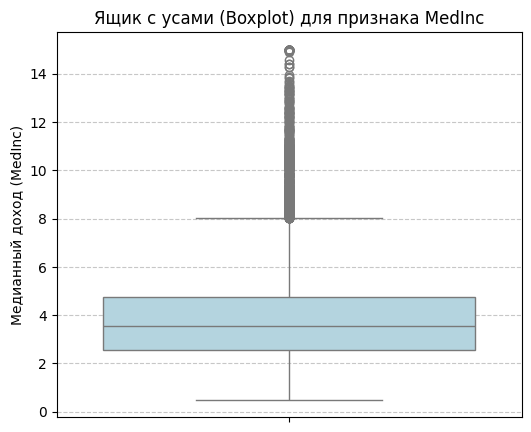

In [6]:
# ============================================================
# ДОПОЛНИТЕЛЬНОЕ ТРЕБОВАНИЕ ДЛЯ ГРУППЫ ИУ5И-23М:
# Boxplot (ящик с усами) для произвольной колонки данных
# ============================================================

plt.figure(figsize=(6, 5))
sns.boxplot(y=df['MedInc'], color='lightblue')
plt.title('Ящик с усами (Boxplot) для признака MedInc', fontsize=12)
plt.ylabel('Медианный доход (MedInc)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Заключение (Conclusion)

1. **Преобразование Йео-Джонсона** - Исходный столбец MedInc имеет правостороннее (right-skewed) распределение.
   После преобразования Йео-Джонсона распределение становится ближе к нормальному распределению (normal distribution).

2. **Отбор признаков** - Согласно взаимной информации (Mutual Information), наибольшую важность для прогнозирования стоимости дома имеет признак Longitude (долгота).
   В соответствии с заданным порогом 5% был выбран только один признак - Longitude.

3. **Boxplot (ящик с усами)** - Для группы ИУ5И-23М построен boxplot для признака MedInc.
   График показывает медиану, межквартильный размах и выбросы, подтверждая асимметрию исходного распределения.